[https://github.com/JuliaGeometry/VoronoiCells.jl](https://github.com/JuliaGeometry/VoronoiCells.jl)

In [1]:
using Pkg
Pkg.activate(; temp=true)         # create a temporary environment


  Activating new project at `/tmp/jl_JiT58I`


In [2]:
Pkg.add(["VoronoiCells", "GeometryBasics", "Plots", "Random"]);
using Random, Plots, GeometryBasics, VoronoiCells


   Resolving package versions...
   Installed Qt6Base_jll ─ v6.7.1+1
   Installed FFMPEG_jll ── v4.4.4+1
   Installed GR_jll ────── v0.73.6+0
   Installed GR ────────── v0.73.6
    Updating `/tmp/jl_JiT58I/Project.toml`
  [5c1252a2] + GeometryBasics v0.4.11
  [91a5bcdd] + Plots v1.40.5
  [e3e34ffb] + VoronoiCells v0.4.0
  [9a3f8284] + Random
    Updating `/tmp/jl_JiT58I/Manifest.toml`
  [d1d4a3ce] + BitFlags v0.1.9
  [944b1d66] + CodecZlib v0.7.5
  [35d6a980] + ColorSchemes v3.26.0
  [3da002f7] + ColorTypes v0.11.5
  [c3611d14] + ColorVectorSpace v0.10.0
  [5ae59095] + Colors v0.12.11
  [34da2185] + Compat v4.15.0
  [f0e56b4a] + ConcurrentUtilities v2.4.2
  [187b0558] + ConstructionBase v1.5.5
  [d38c429a] + Contour v0.6.3
  [9a962f9c] + DataAPI v1.16.0
  [864edb3b] + DataStructures v0.18.20
  [e2d170a0] + DataValueInterfaces v1.0.0
  [8bb1440f] + DelimitedFiles v1.9.1
  [ffbed154] + DocStringExtensions v0.9.3
  [460bff9d] + ExceptionUnwrapping v0.1.10
  [411431e0] + Extents v0.1.3
  [

[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


In [5]:
rng = Random.MersenneTwister(1337)
rect = Rectangle(Point2(0, 0), Point2(1, 1))
points = [Point2(rand(rng), rand(rng)) for _ in 1:10]

10-element Vector{Point{2, Float64}}:
 [0.22658190197881312, 0.5046291972412908]
 [0.9333724636943255, 0.5221721267193593]
 [0.5052080505550971, 0.09978246027514359]
 [0.04432218813798294, 0.7229058081423172]
 [0.8128138585478044, 0.24545709827626805]
 [0.11201971329803984, 0.0003419958128361156]
 [0.3800005018641015, 0.5052774551949404]
 [0.8411766784932724, 0.3265612016334474]
 [0.8108569785026885, 0.8504559154148246]
 [0.47805314311674496, 0.17906582198336407]

In [6]:
tess = voronoicells(points, rect);

In [7]:
tess.Cells[1]

5-element Vector{Point{2, Float64}}:
 [0.0, 0.5006658246439755]
 [0.0, 0.290946757178257]
 [0.2213254892928772, 0.24066681274894675]
 [0.3041376415938776, 0.3046324682958502]
 [0.30224294454977085, 0.7530369438246255]

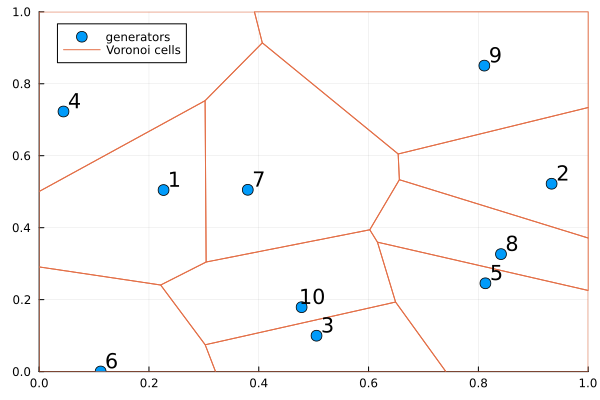

In [8]:
scatter(points, markersize = 6, label = "generators")
annotate!([(points[n][1] + 0.02, points[n][2] + 0.03, Plots.text(n)) for n in 1:10])
plot!(tess, legend = :topleft)

In [9]:
voronoiarea(tess)

10-element Vector{Float64}:
 0.10905486942527852
 0.07490860886924389
 0.05461848195251296
 0.12952276262421542
 0.09433209871294435
 0.07231514118679605
 0.14583818637774282
 0.0629555617755161
 0.1745766432353954
 0.08187764584035451

In [10]:
extended_points = vcat(points, VoronoiCells.corners(rect))
extended_tess = voronoicells(extended_points, rect);

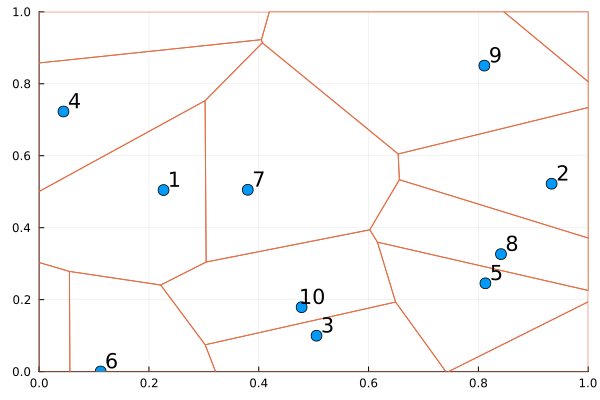

In [11]:
scatter(points, markersize = 6, label = "generators")
annotate!([(points[n][1] + 0.02, points[n][2] + 0.03, Plots.text(n)) for n in 1:10])
plot!(extended_tess, legend = :none)